# Oscars-Effect -- does the market care who wins Best Picture?
### A cultural-event indicator, tested honestly, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Yes](https://img.shields.io/badge/Busted%3F-Yes-8b949e?style=flat-square)

Every March, tens of millions of people watch the Academy Awards. The winning films get a real box-office bump. So surely -- the intuition goes -- such a giant cultural event must *move the market* the next morning? This notebook asks the only question that matters: when you look at the S&P 500 on the first trading day after the Oscars, across 31 ceremonies, is there anything there at all?

> **This is the plain-language layer.** Want the event-study abnormal returns, the HAC t-stats, and the placebo control? That's **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from oscars_effect import data, strategy as st

def _have_cache():
    try:
        data.fetch_daily(fetch=False)
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("^GSPC cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17)
R = dict(
    n_obs=8165, n_events=31,
    baseline_mean_bps=4.1, baseline_up_pct=54.0,
    event_mean_bps=-23.8, abnormal_bps=-27.9,
    event_hac_t=-1.35, event_plain_t=-1.13, event_up_pct=45.2,
    car_full_bps=-10.9,
    aar_m1=26.8, t_m1=1.67, aar_0=-27.9, t_0=-1.32, aar_p1=19.4, t_p1=0.74,
    aar_p2=-8.5, t_p2=-0.59, aar_p3=-20.7, t_p3=-1.22,
    trade_gross_bps=-23.8, trade_net_bps=-25.8, trade_net_t=-1.46, trade_bah_bps=-23.8,
    placebo_p=0.183, mde_bps=40.0, daily_vol_bps=110.0,
    year_start=1995, year_end=2025,
)
REL_DAYS = [-1, 0, 1, 2, 3]
AAR_FROZEN = [R['aar_m1'], R['aar_0'], R['aar_p1'], R['aar_p2'], R['aar_p3']]
T_FROZEN   = [R['t_m1'], R['t_0'], R['t_p1'], R['t_p2'], R['t_p3']]


^GSPC cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the market rally the day after the Oscars? | **No.** The mean move is **-23.8 bps** -- if anything mildly *down*, up only 45.2% of the time vs a 54.0% baseline. HAC t = -1.35: pure noise. |
| Is the winning film's box-office bump real? | **Yes -- and irrelevant here.** The bump accrues to *one film's* revenue; it is a rounding error for a diversified media giant, let alone the whole index. |
| Could you trade it? | **No.** A 'buy the morning after' rule loses money even before costs. There is no vehicle and no edge. |
| How many ceremonies? | **31** (1995-2025) -- far too few to detect anything smaller than ~40 bps even if it existed. |

> The Oscars move red carpets and a few studio share prices at the margins. The broad index registers nothing the next morning beyond ordinary daily noise.

## 1 - The claim

> *"The Academy Awards are one of the biggest cultural events of the year. The whole country is watching, the winning studios get a windfall, and the mood is set for the season -- so the stock market must react to who wins Best Picture."*

Unlike the Super Bowl Indicator, there's no famous paper behind this -- it's *folklore by analogy*. There genuinely **is** an 'Oscar bump' in box office for the winning film. The leap of faith is that this local, firm-level effect shows up in the **broad index** the next trading morning.

## 2 - So what?

If a single, perfectly-scheduled cultural event reliably nudged the whole S&P 500 the next morning, it would be the easiest trade in finance: you know the date years in advance. That alone should make you suspicious. Markets price information when it arrives -- and by Oscar night, the winners are already heavily implied by the precursor awards and the betting markets. There is almost nothing new to learn.

## 3 - How would we even know?

We run a clean **event study**:

1. **Event day 0** is the first *full* trading session after the broadcast (the ceremony airs Sunday/Monday evening, so this is the earliest you could trade -- one execution lag, baked in). We never use the ceremony evening itself.
2. **Abnormal return** = the event-day mean minus the market's ordinary daily mean. If the Oscars matter, this should be reliably non-zero.
3. **The honest baseline.** The S&P drifts up ~4 bps/day and is positive ~54% of days regardless. The question is whether the morning after the Oscars beats *that*, not a coin.
4. **Tiny n.** Only 31 ceremonies sit inside the ^GSPC daily window. With ~110 bps daily volatility, we could only detect an effect bigger than ~40 bps. We'll check whether the observed move is anywhere near that.

Real tape: ^GSPC daily, 1994-2026 (31 ceremonies, 1995-2025).

## 4 - The teardown -- let's actually look

**First, meet the data:** every Oscar ceremony, hardcoded in this study's `data.py`, with its Best Picture winner.

In [2]:
cer = data.oscar_table()
print('Ceremonies:', len(cer), '(67th-97th, 1995-2025)')
print(cer[['ceremony','date','best_pic']].tail(6).to_string(index=False))
print()
if HAVE_REAL:
    ret, cer = data.fetch_daily()
    base = float(ret.mean()*1e4); base_up = float((ret>0).mean()*100)
else:
    base, base_up = R['baseline_mean_bps'], R['baseline_up_pct']
print(f'Baseline daily mean: {base:+.1f} bps,  up {base_up:.1f}% of days')
print('This is what the morning-after move must beat -- not a coin.')

Ceremonies: 31 (67th-97th, 1995-2025)
 ceremony       date                          best_pic
       92 2020-02-09                          Parasite
       93 2021-04-25                         Nomadland
       94 2022-03-27                              CODA
       95 2023-03-12 Everything Everywhere All at Once
       96 2024-03-10                       Oppenheimer
       97 2025-03-02                             Anora

Baseline daily mean: +4.1 bps,  up 54.0% of days
This is what the morning-after move must beat -- not a coin.


**The morning after -- average move by relative day around the ceremony.**

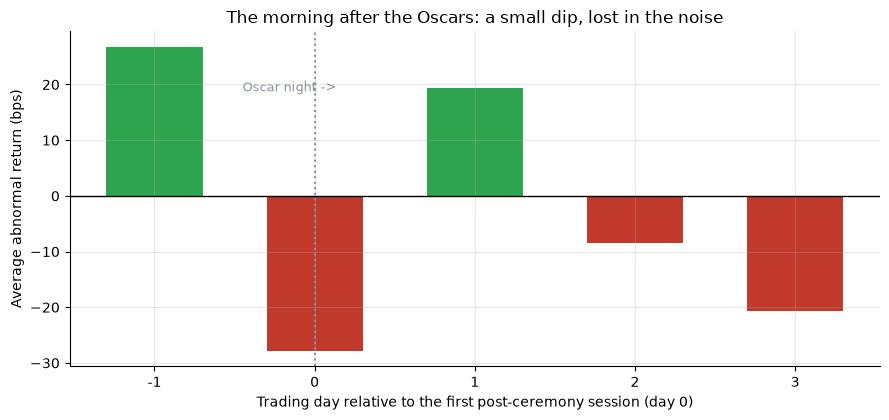

Event-day-0 abnormal return: -27.9 bps


In [3]:
if HAVE_REAL:
    w = data.event_windows(ret, cer, pre=1, post=3)
    car = st.car_profile(ret, w)
    rel = car['rel_day'].tolist(); aar = car['aar_bps'].tolist()
else:
    rel, aar = REL_DAYS, AAR_FROZEN

fig, ax = plt.subplots(figsize=(9.0, 4.3))
colors = [GREEN if a>=0 else RED for a in aar]
ax.bar([str(d) for d in rel], aar, color=colors, width=0.6)
ax.axhline(0, c='k', lw=1)
ax.axvline(1.0, ls=':', c=GREY, lw=1.5)  # event day 0 is the 2nd bar (index 1)
ax.annotate('Oscar night ->', (0.55, max(aar)*0.7), color=GREY, fontsize=9)
ax.set_xlabel('Trading day relative to the first post-ceremony session (day 0)')
ax.set_ylabel('Average abnormal return (bps)')
ax.set_title('The morning after the Oscars: a small dip, lost in the noise')
plt.tight_layout(); plt.show()
print('Event-day-0 abnormal return:', f"{aar[1]:+.1f} bps")

Event day 0 -- the first morning you could actually trade -- averages a small **negative** move (about **-28 bps** abnormal). That's the *opposite* of the 'cultural-event rally' story, and it is tiny relative to the day-to-day noise. The bars to either side bounce around zero with no pattern.

**Was that dip ever big enough to matter? The base-rate / size check.**

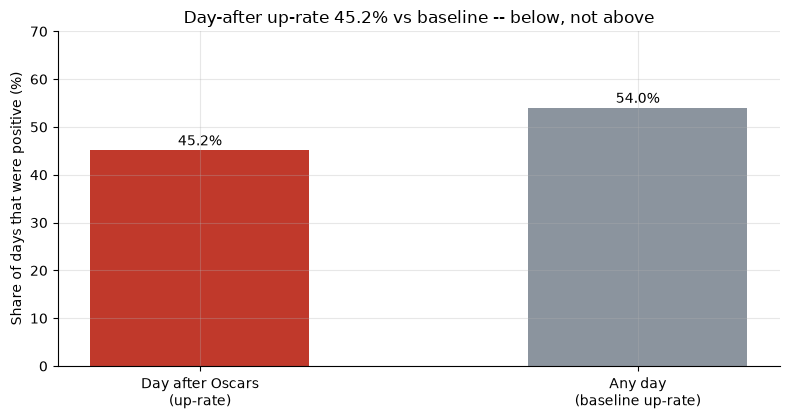

Day-after mean: -23.8 bps  |  abnormal vs baseline: -27.9 bps
Up-rate 45.2% is BELOW the ~54% baseline -- no rally here.


In [4]:
if HAVE_REAL:
    et = st.event_day_test(ret, w)
    ev_up = et['up_rate']*100; ev_mean = et['event_mean_bps']; ab = et['abnormal_bps']
else:
    ev_up, ev_mean, ab = R['event_up_pct'], R['event_mean_bps'], R['abnormal_bps']

fig, ax = plt.subplots(figsize=(8.0, 4.3))
bars = ax.bar(['Day after Oscars\n(up-rate)', 'Any day\n(baseline up-rate)'],
              [ev_up, base_up if HAVE_REAL else R['baseline_up_pct']],
              color=[RED, GREY], width=0.5)
ax.set_ylabel('Share of days that were positive (%)'); ax.set_ylim(0, 70)
ax.set_title(f'Day-after up-rate {ev_up:.1f}% vs baseline -- below, not above')
for b, v in zip(bars, [ev_up, base_up if HAVE_REAL else R['baseline_up_pct']]):
    ax.annotate(f'{v:.1f}%', (b.get_x()+b.get_width()/2, v+1), ha='center')
plt.tight_layout(); plt.show()
print(f'Day-after mean: {ev_mean:+.1f} bps  |  abnormal vs baseline: {ab:+.1f} bps')
print(f'Up-rate {ev_up:.1f}% is BELOW the ~54% baseline -- no rally here.')

The day after the Oscars the market was up only **45.2%** of the time -- *below* the 54% you'd get on a random day. There is no rally; there is a faint, statistically meaningless dip. With only 31 observations, this is exactly what pure noise looks like.

## 5 - The verdict

- **Signal -- None.** Day-0 abnormal return **-27.9 bps**, HAC t = **-1.35**, placebo p = **0.18**. No day in the window clears the significance bar, and the tiny tilt runs *opposite* to the folklore.
- **Tradability -- Mirage.** A 'buy the morning after' rule loses money before costs (see Beat 6). There is no vehicle and no edge.
- **Busted.** The Oscar bump is real but *local* -- it lifts the winning film's box office, not the S&P 500. The index does not care who wins Best Picture.

## 6 - Could you actually trade it?

The most generous tradeable rule: buy the index the morning after each ceremony, hold one session, repeat every year. Net of a one-way cost on entry and exit:

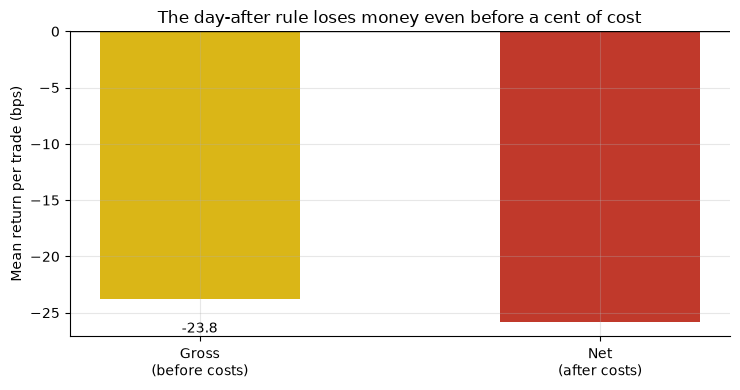

Gross per trade: -23.8 bps  |  Net per trade: -25.8 bps
There is no edge to harvest; costs only deepen the hole.


In [5]:
if HAVE_REAL:
    tr = st.tradable_rule(ret, w, hold_days=1, cost_bps_one_way=1.0)
    gross, net = tr['gross_mean_bps'], tr['net_mean_bps']
else:
    gross, net = R['trade_gross_bps'], R['trade_net_bps']

fig, ax = plt.subplots(figsize=(7.5, 4.0))
bars = ax.bar(['Gross\n(before costs)', 'Net\n(after costs)'],
              [gross, net], color=[AMBER, RED], width=0.5)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Mean return per trade (bps)')
ax.set_title('The day-after rule loses money even before a cent of cost')
for b, v in zip(bars, [gross, net]):
    ax.annotate(f'{v:+.1f}', (b.get_x()+b.get_width()/2, v-2), ha='center', va='top')
plt.tight_layout(); plt.show()
print(f'Gross per trade: {gross:+.1f} bps  |  Net per trade: {net:+.1f} bps')
print('There is no edge to harvest; costs only deepen the hole.')

The rule is in the red **before** costs (-23.8 bps/trade) -- so there is nothing for costs to eat into; they just make a bad trade worse. The only real lesson: do not time the market on the Academy Awards.

## 7 - Going further

- **The positive control:** the companion notebook plants a fake post-Oscar bump in a synthetic tape and shows the engine detects a ~50 bps effect easily. The real tape has nothing like that -- the null is a true absence, not a power failure.
- **The Super Bowl Indicator** -- the same 'a cultural event predicts the market' folklore: [Study 158 -- Super-Bowl](../../158-super-bowl/).
- **Mercury retrograde** -- the same daily ^GSPC event machinery on financial astrology: [Study 164 -- Mercury-Retrograde](../../164-mercury-retrograde/).

*Think the Oscars really do move the tape? Fork this, define your own event window or studio-level basket, and show an abnormal return that clears |t| >= 2. That's the bar -- and the broad index does not clear it.*